# Customer Churn Prediction

## Model Interpretation

### Objective

Model evaluation notebook established that the model works (ROC-AUC 0.853, tuned recall 0.70) and used permutation importance to get an honest, unbiased read on which features matter overall. This notebook goes one level deeper: it explains why the model makes the
specific predictions it does, translates those mechanics into concrete business actions, and is honest about what this project does and doesn't establish.

**This notebook covers:**
1. A recap of global feature importance (permutation importance, carried over from previous notebook)
2. SHAP values both global patterns and individual, per-customer explanations
3. Business recommendations grounded directly in what the model found
4. Final conclusions
5. Limitations
6. Future work

This is the step that turns a working model into a decision-support tool someone could actually act on.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

import shap

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


### Load the model and reconstruct the test set

Same approach as before, the exact split is reproduced from the saved
feature CSV using the same `random_state`, so this notebook explains the model on the same held-out customers it was evaluated on.

In [2]:
with open("../models/trained_model.pkl", "rb") as f:
    model = pickle.load(f)

df_unscaled = pd.read_csv("../data/processed/bank_customer_churn_features.csv")
X = df_unscaled.drop(columns=["churn"])
y = df_unscaled["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Loaded model:", type(model).__name__)
print("Test shape:", X_test.shape)


Loaded model: RandomForestClassifier
Test shape: (2000, 20)


### Recap: global feature importance (permutation importance)

This repeats the permutation importance analysis as a
starting point, SHAP values below will show how these top features actually push individual predictions up or down, not just that they matter on average.

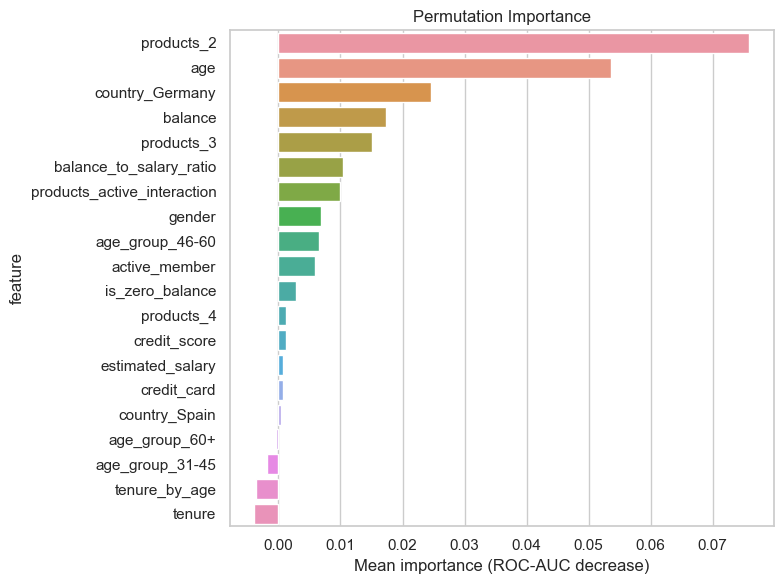

In [4]:
perm_result = permutation_importance(
    model, X_test, y_test, scoring="roc_auc",
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=perm_importance_df, x="importance_mean", y="feature")
plt.title("Permutation Importance") #Recap from model evaluation
plt.xlabel("Mean importance (ROC-AUC decrease)")
plt.tight_layout()
plt.show()


### SHAP values: global patterns

Permutation importance answers "how much does this feature matter overall?" SHAP (Shapley Additive exlanations) goes further: it shows which direction each feature pushes a prediction, and how that effect varies across different customers. `TreeExplainer` is used since Random Forest is a tree-based model, which allows SHAP to compute exact values efficiently rather than approximating them.

In [5]:
explainer = shap.TreeExplainer(model)
shap_explanation = explainer(X_test)

print("SHAP Explanation shape:", shap_explanation.shape)
print("Output names:", getattr(shap_explanation, "output_names", None))


SHAP Explanation shape: (2000, 20, 2)
Output names: ['Output 0', 'Output 1']


Random Forest is a binary classifier, so `shap_explanation` has one set of values per
class. The cell below isolates the **churn (positive) class** — index `1` — so every plot
that follows shows "what pushes this prediction toward churn," not toward retention.

In [6]:
# Isolate the churn class if the explanation has a class axis (ndim == 3);
# some SHAP/model configurations return a single set of values already (ndim == 2)
if shap_explanation.values.ndim == 3:
    shap_churn = shap_explanation[:, :, 1]
else:
    shap_churn = shap_explanation

print("Churn-class SHAP values shape:", shap_churn.values.shape)


Churn-class SHAP values shape: (2000, 20)


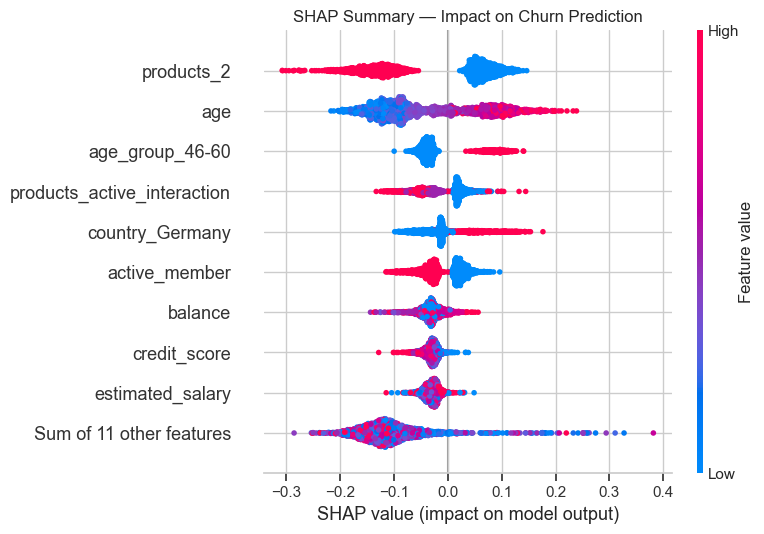

In [7]:
shap.plots.beeswarm(shap_churn, show=False)
plt.title("SHAP Summary — Impact on Churn Prediction")
plt.tight_layout()
plt.savefig("../images/shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading this plot:** each dot is one customer. Position on the x-axis shows how much that feature pushed *that customer's* prediction toward churn (right) or retention (left). Color shows whether the customer had a high (red) or low (blue) value for that feature.
This is what turns "products_2 matters" into "having 2 products specifically *lowers* churn risk, and having 1 or 3+ products raises it" the direction, not just the magnitude.

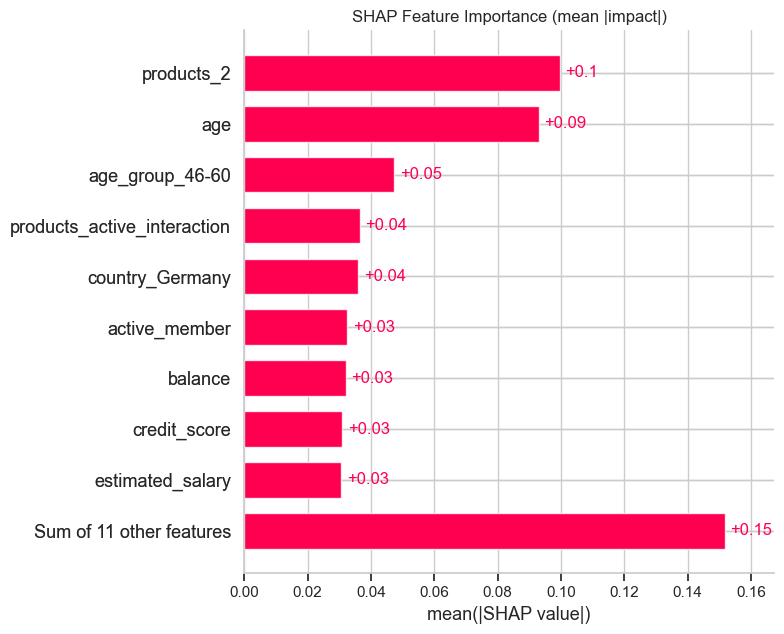

In [8]:
shap.plots.bar(shap_churn, show=False)
plt.title("SHAP Feature Importance (mean |impact|)")
plt.tight_layout()
plt.savefig("../images/shap_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()


**Caveat on this ranking:** this bar chart should be read alongside, not instead of, the permutation importance recap above. `credit_score` and `estimated_salary` show moderate
SHAP magnitude here despite contributing almost nothing to actual model performance (permutation importance ≈ 0 for both) a milder version of the same bias that affected Random Forest's built-in impurity-based importance in `05_model_training.ipynb`. The beeswarm plot above (direction of effect per feature) is unaffected by this and remains fully trustworthy; it's specifically this bar chart's *ranking* that can be inflated by continuous, high-cardinality features Random Forest splits on frequently, whether or not those splits actually help predictive performance.

### SHAP values: individual customer explanations

Global importance is useful for understanding the model overall, but a retention team acting on a specific flagged customer needs to know *why that customer* was flagged. Below, one correctly-identified churned customer and one correctly-identified retained customer
are explained individually using waterfall plots, which show exactly how each feature pushed that one prediction away from the model's average output.

In [9]:
y_pred_default = model.predict(X_test)

# Pick one true positive (correctly predicted churn) and one true negative
# (correctly predicted retained) for illustration
churned_idx = X_test[(y_test == 1) & (y_pred_default == 1)].index[0]
retained_idx = X_test[(y_test == 0) & (y_pred_default == 0)].index[0]

churned_pos = X_test.index.get_loc(churned_idx)
retained_pos = X_test.index.get_loc(retained_idx)

print("Example churned customer (index):", churned_idx)
print("Example retained customer (index):", retained_idx)


Example churned customer (index): 7068
Example retained customer (index): 5702


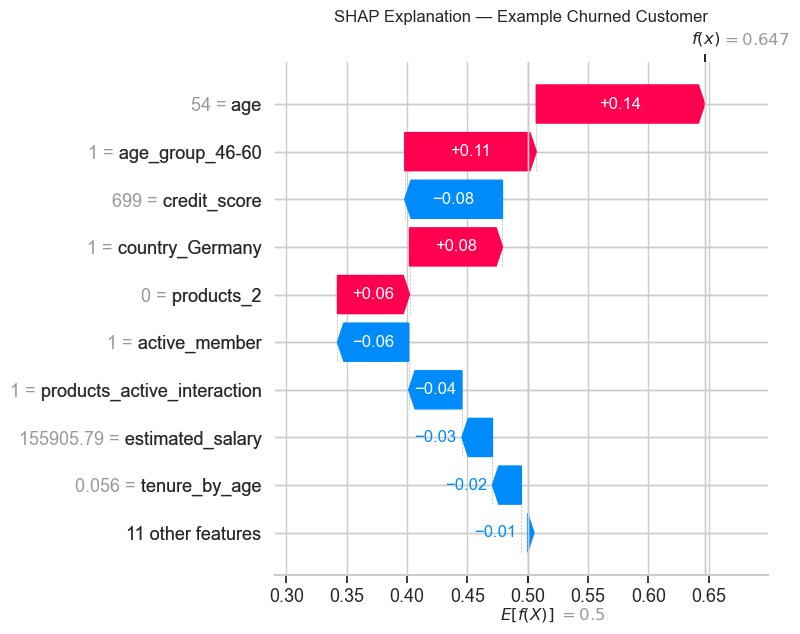

In [10]:
# shap_churn supports direct positional indexing since it's already an Explanation object
shap.plots.waterfall(shap_churn[churned_pos], show=False)
plt.title("SHAP Explanation — Example Churned Customer")
plt.tight_layout()
plt.savefig("../images/shap_waterfall_churned_example.png", dpi=300, bbox_inches="tight")
plt.show()


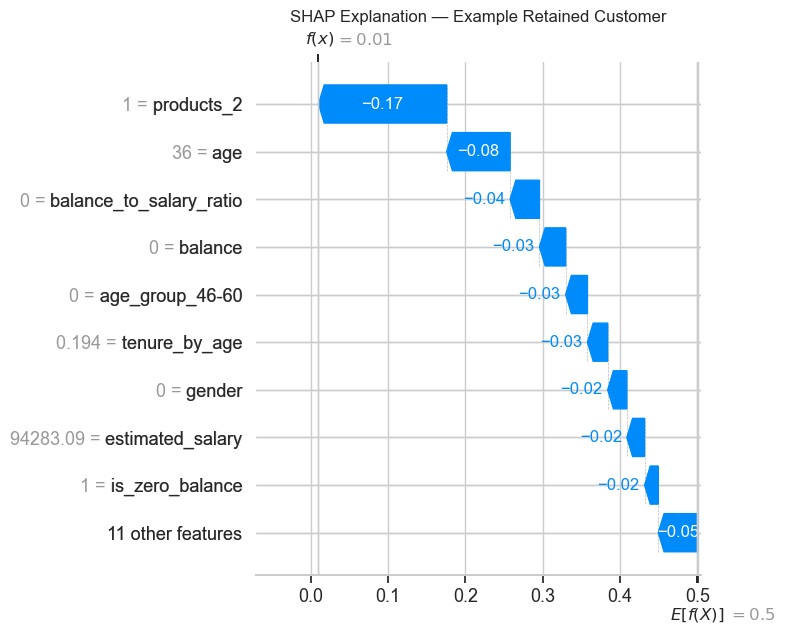

In [11]:
shap.plots.waterfall(shap_churn[retained_pos], show=False)
plt.title("SHAP Explanation — Example Retained Customer")
plt.tight_layout()
plt.savefig("../images/shap_waterfall_retained_example.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading these plots:** each bar shows one feature's contribution for that one customer, starting from the model's average prediction (`E[f(X)]`) and ending at that customer's actual predicted value. Red bars push the prediction toward churn; blue bars push it toward retention. This is the level of detail a retention team would need to explain to a manager or even to the customer why they were flagged.

**Note on the baseline value:** `E[f(X)] = 0.5` here, not the dataset's true ~20% churn rate. This is expected, not an error, the model was trained with `class_weight="balanced"` which reweights training samples internally so the model's raw predicted probabilities center around 0.5 rather than the true base rate. This reinforces the "uncalibrated probabilities" limitation noted later
in this notebook: this model's raw `predict_proba()` output should not be read as a literal likelihood of churn without calibration (e.g. `CalibratedClassifierCV`).

## Business Recommendations

These recommendations follow directly from the SHAP and permutation importance findings above — each one is traceable back to a specific pattern the model actually found, not a generic churn-prevention checklist.

1. **Target customers with exactly 1 product for cross-sell.** `products_2` is the single strongest predictor of retention. Customers with only 1 product are meaningfully higher-risk; a targeted campaign encouraging them toward a second product (savings account, credit product, etc.) directly addresses the model's top signal.

2. **Investigate the 3-4 product segment as a distinct, high-risk group not a success story.** Counterintuitively, customers holding 3 or 4 products churn at the *highest* rates in the dataset. This likely reflects a different underlying cause (e.g.dissatisfaction leading to closing/downgrading products before leaving entirely, or these products being sold to customers who didn't want them). This segment is small (326 of 10,000 customers) but worth a targeted service review rather than being ignored because it's outnumbered by the "more products = more loyalty" intuition.

3. **Prioritize retention outreach for older customers.** Age is the second-strongest driver, and consistently pushes predictions toward churn as it increases. A proactive check-in program for customers above the ~45-50 age range (see the EDA's age distribution by churn) could catch at-risk customers before they act.

4. **Review service quality specifically in Germany.** Germany shows both a higher churn rate in the EDA and meaningful SHAP importance, this isn't just a demographic artifact, it's a distinguishing factor the model relies on. Worth investigating market-specific service issues, competitor activity, or regulatory factors unique to
   that market.

5. **Flag high-balance, inactive customers as a combined risk group.** Balance and active membership both matter individually, but the EDA and SHAP results together suggest the riskiest customers are high-balance and inactive simultaneously, valuable customers who've quietly disengaged. These customers justify a higher-touch retention approach (relationship manager outreach) given their financial value.

6. **Use the model's probability score, not just the yes/no flag, to prioritize outreach effort.** Since the tuned threshold (0.247) deliberately over-flags to catch more churners, treating every flagged customer identically would waste effort on borderline cases. Ranking flagged customers by their raw probability score lets the retention team focus first on the highest-confidence predictions.


## Final Conclusions

This project built a complete churn prediction pipeline from raw data through a tuned, interpretable model and validated every major decision along the way with evidence rather than assumption:

- The EDA's key hypotheses (age, active membership, balance, and products_number as the strongest churn drivers) were confirmed by both permutation importance and SHAP in the final model, giving confidence that the model has learned real patterns rather than noise.
- The non-monotonic relationship between products_number and churn, an easy pattern to miss with a naive numeric encoding turned out to be the single most important feature in the final model, justifying the extra care taken during feature engineering.
- Choosing a model wasn't just about picking the highest ROC-AUC: Random Forest's default threshold under-caught churners badly (45% recall), and required explicit tuning (to 70% recall) before it was actually usable for the stated business goal.
- Random Forest's built-in feature importance was actively misleading (over-ranking `estimated_salary` and `credit_score`), and would have led to incorrect business recommendations if taken at face value instead of being corrected with permutation importance and SHAP.

The final model, at its tuned threshold, catches 70% of churners with a precision of 50%, a deliberate trade-off favoring not missing at-risk customers over minimizing false alarms, consistent with the reasoning that a missed churner is costlier than an unnecessary retention offer.


## Limitations

- **Threshold choice is not backed by real financial data.** The 0.247 threshold assumes missing a churner is meaningfully costlier than a false alarm, but no actual retention campaign cost or customer lifetime value data was available to quantify that trade-off precisely. A different threshold could be more appropriate with real cost figures.
- **No temporal validation.** The train/test split is a random stratified split, not a time-based split. In a real deployment, customer behavior and churn patterns can shift over time (concept drift), and this project doesn't test whether the model holds up on
  *future* customers, only on a held-out random sample of the same historical data.
- **Small subgroup sizes create instability risk.** Only 266 customers hold 3 products and 60 hold 4 products (out of 10,000). The model's behavior on this segment despite being highly important is based on a small sample and could be less reliable than the aggregate metrics suggest.
- **Uncalibrated probabilities.** Random Forest's `predict_proba()` output isn't guaranteed to reflect true probabilities (e.g., a 0.7 output doesn't necessarily mean a true 70% likelihood of churn). This matters if probability scores are used directly for prioritization, as recommended above, rather than just for ranking.
- **Limited feature scope.** The dataset only includes demographic and account-level snapshot data, no transaction history, customer service interactions, complaints, or competitor activity, all of which likely influence real churn decisions.
- **Geographic scope is narrow.** The dataset covers only three countries (France, Spain, Germany) findings, especially the Germany specific pattern, may not generalize to other markets.
- **SHAP and permutation importance show association, not causation.** These methods explain what the *model* relies on, not necessarily the true causal drivers of churn in the real world. A/B testing any resulting business intervention (e.g. the cross-sell recommendation) would be needed to confirm real-world causal impact.


## Future Work

- **Acquire real cost data** (retention campaign cost, customer lifetime value) to move threshold selection from a reasonable assumption to a data-backed, cost-optimal decision.
- **Drop `tenure` and `tenure_by_age`**, which showed negative permutation importance and confirm whether removing them simplifies the model without hurting (or even slightly improving) performance.
- **Test time-based validation** (e.g. training on earlier customers, testing on more recent ones, if timestamps become available) to check for concept drift and get a more realistic estimate of future performance.
- **Calibrate the model's probabilities** using `CalibratedClassifierCV`, so probability scores can be trusted directly for prioritization rather than only for ranking.
- **Investigate the 3-4 product segment directly** with qualitative research (customer interviews, support ticket review) to understand why this group churns so heavily, since the model can show that they do but not why.
- **Expand the feature set** with behavioral and interaction data transaction frequency, support ticket volume, complaint history if it becomes available, since the current dataset is limited to demographic and account snapshot fields.
- **A/B test the top business recommendation** (targeted cross-sell to single-product customers) to validate that acting on the model's findings actually reduces churn, closing the loop from prediction to causal impact.
